## Example of SDE-matching using a Gaussian Process as marginal distribution

We define a data generating process by the following SDE:
$$
dz_t = f(z_t, t) dt + g(z_t, t) dW_t = \begin{bmatrix}
0 & 2 \\
-2 & 0
\end{bmatrix} z_t d_t + 0.6 \cdot dWt
$$

with emission distribution $y_t \sim \mathcal N(y_t\vert z_t, 0.3^2)$ and initial conditions: $z_0 \sim \mathcal N(0, I_2)$. 


This model is a classic pendulum model. In this case we assume that we can only observe the position -- that is the first dimension. 

The task is to reconstruct the drift matrix $A=\begin{bmatrix}
0 & 2 \\
-2 & 0
\end{bmatrix}$, the diffusion constant $\sigma_d = 0.6$, the observation noise $\sigma_e = 0.3$ and the initial condition distribution $\mathcal N(0, I_2)$.

Note that since we only observe the first dimension, there are many SDE's that can generate the same observations. 
Indeed, if 
$A=\begin{bmatrix}
0 & 2 \\
-2 & 0
\end{bmatrix},$ then any matrix $A'=\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}$ where trace and determinant are the same as for $A$ will generate the same process in the first dimension. That means that as long as $a+d=0$ and $ad - bc=4$ we will see the same observed process. In other words, there are two free parameters in the model. 

But in this specific case we know that the system is energy conserving, we can safely assume that the drift matrix is skew-diagonal. That is: $A'=\begin{bmatrix}
0 & p \\
-p & 0
\end{bmatrix}$.

In [1]:
# First some imports
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import matplotlib
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from SDEmatching.distributions.Emission import GaussianEmission
from SDEmatching.distributions.Prior import GaussianPrior
from SDEmatching.core.Diffusions import ScalarDiffusion, SimpleDiffusion
from SDEmatching.core.Marginal import Marginal
from SDEmatching.models.Flows import DDPMflow, NormalFlow, AffineFlow
from SDEmatching.core.SDE import SimpleSDE, SDE, manual_euler_sample
from SDEmatching.utils.utils import torch_seed, to_tensor, mask_and_pad, save_models
import seaborn as sns
from SDEmatching.utils.datageneration import SDEdatagenerator
from SDEmatching.core.SDEproblem import SDEproblem
from plot_functions import plot_parameter_history, plot_marginal
from SDEmatching.models.ConditionMappers import TransformerLatentModel
from SDEmatching.models.GaussianProcessDerivative import GPLatentModel, RBFKernel, PeriodicKernel
import math
import numpy as np
import normflows as nf
from torch.utils.data import DataLoader, TensorDataset
import copy
import pandas as pd
#torch.autograd.set_detect_anomaly(True)

In [2]:
# set constants
num_timesteps = 30
num_ts_samples = 30
num_series = 200
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

state_dim = 2
observation_dim = 1
t_start = -1
t_end = 1
time_dist = torch.distributions.Uniform(t_start, t_end)

true_diffusion_log_std = torch.tensor(.6).log()
true_prior_log_std = (torch.ones(state_dim, device=device)).log()
true_emission_log_std = torch.tensor(.3).log()

In [3]:
"""
Generating data
"""
# diffusion function  
generator_diffusion = SimpleDiffusion(brownian_dim=2, state_dim=state_dim, log_std=true_diffusion_log_std, device=device, trainable=True)

# drift function
class LinearDrift(torch.nn.Module):
    def __init__(self, state_dim, device='cpu'):
        super().__init__()
        self.state_dim = state_dim
        self.device    = device
        self.linear = torch.nn.Linear(state_dim, state_dim, bias=False).to(device)

    def forward(self, state, ts=None):
        return self.linear(state)

generator_drift = LinearDrift(state_dim=state_dim, device=device)
generator_drift.linear.weight.data = torch.tensor([[0., 2.], [-2., 0.]], device=device)

# prior
generator_prior = GaussianPrior(mean=torch.ones(state_dim, device=device) * 0., log_std=true_prior_log_std, device=device, trainable=True)

# emission distribution:
#generator_emission = GaussianEmission(dim=state_dim, log_std=true_emission_log_std, device=device, trainable=True)
generator_emission = GaussianEmission(dim=state_dim, observation_dim=observation_dim, log_std=true_emission_log_std, device=device, trainable=True)

# put together the SDE
generator_SDE = SDE(generator_drift, generator_diffusion, generator_prior, steps=num_timesteps, t_start=t_start, t_end=t_end, device=device)
#list_of_timeseries = SDEdatagenerator(generator_SDE, generator_emission, time_dist, num_series=11, mean_num_ts=10, same_ts=False, num_ts_samples=None, device=device)

# generate data
list_of_timeseries, list_of_state_timeseries = SDEdatagenerator(generator_SDE, generator_emission, time_dist, num_series=num_series, same_ts=False, mean_num_ts=num_ts_samples, device=device, seed=2)

# convert to tensors
true_state_series = torch.stack([state_timeseries for state_timeseries in list_of_state_timeseries]).detach().clone()

# The time series have different lengths, so we need pad them and define a mask to be able to use them in batches. 
data, emissions_mask = mask_and_pad(list_of_timeseries, list_of_state_timeseries, observation_dim, device)

/var/folders/t_/nfzp77bj23v7ypcy679dgp_80000gn/T/ipykernel_49867/1788713067.py:13: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4483.)
  _=plt.plot(data[i, ~emissions_mask[i],0].T.detach().cpu(), data[i, ~emissions_mask[i],1].T.detach().cpu(), marker="x", linewidth=0, c=color, label=emmission_label)


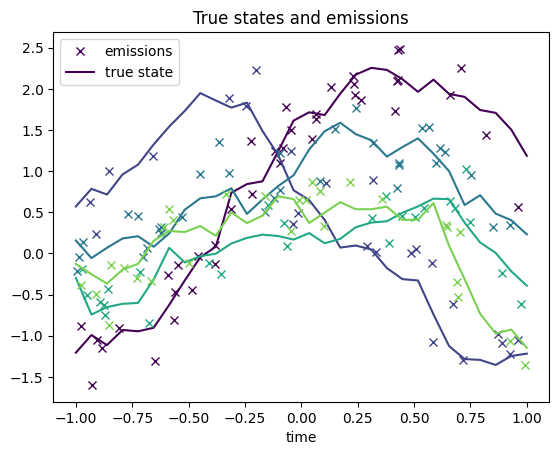

In [4]:
# Plotting some paths and emissions
cmap = matplotlib.colormaps["viridis"]
series_to_plot=min(5, data.shape[0])
for i in range(series_to_plot):
    color = cmap(i/series_to_plot)
    if i == 0:
        emmission_label = "emissions"
        state_label = "true state"
    else:        
        emmission_label = None
        state_label = None
    
    _=plt.plot(data[i, ~emissions_mask[i],0].T.detach().cpu(), data[i, ~emissions_mask[i],1].T.detach().cpu(), marker="x", linewidth=0, c=color, label=emmission_label)
    _=plt.plot(generator_SDE.ts.detach().cpu(), true_state_series[i,:,0].T.detach().cpu(), marker="", c=color, label=state_label)
    plt.xlabel("time")
    plt.title("True states and emissions")
    plt.legend()
plt.show()

## Define model setup for training
We define a model of the same class as the generating model:
$$
dz_t = f(z_t, t) dt + g(z_t, t) dW_t = A_\theta z_t d_t + \sigma_\theta \cdot dWt
$$

with emission distribution: $y_t \sim \mathcal N(y_t\vert z_t, \sigma^2_y)$ and initial conditions: $z_0 \sim \mathcal N(\mu_I, \sigma^2_I \cdot I_2)$. We use a special class for the skew-symmetric drift matrix $A$.

In [5]:
class SkewSymmetricLinear(torch.nn.Module):
    """
    A linear layer restricted to skew-symmetric matrices: A = P - P^T
    Only the upper triangular entries are learnable; diagonal is zero
    and lower triangle is determined by skew-symmetry.
    
    For state_dim=2: A = [[0, p], [-p, 0]] with 1 parameter.
    """
    def __init__(self, state_dim, device='cpu'):
        super().__init__()
        self.state_dim = state_dim
        self.device    = device

        # Only upper triangle parameters
        n_upper = state_dim * (state_dim - 1) // 2
        self.upper_params = torch.nn.Parameter(
            torch.randn(n_upper, device=device) * 0.1
        )

        # Precompute upper triangle indices
        upper = torch.triu_indices(state_dim, state_dim, offset=1)
        self.row_idx = upper[0]
        self.col_idx = upper[1]

    def get_matrix(self):
        P = torch.zeros(self.state_dim, self.state_dim, device=self.device)
        P[self.row_idx, self.col_idx] = self.upper_params
        return P - P.T  # skew-symmetric by construction

    def forward(self, state, ts=None):
        return state @ self.get_matrix().T

In [6]:
# Prior
priormean = torch.zeros(state_dim, device=device)
prior_log_std = true_prior_log_std.clone().detach()
myprior = GaussianPrior(mean=priormean, log_std=prior_log_std, trainable=True, device=device)

# Diffusion term
mydiffusion = SimpleDiffusion(state_dim, state_dim, log_std=true_diffusion_log_std.clone().detach(), device=device, trainable=True)

# Drift term
mydrift = SkewSymmetricLinear(state_dim=state_dim, device=device)

# Emission distribution:
myemission = GaussianEmission(dim=state_dim, observation_dim=observation_dim, log_std=true_emission_log_std.clone().detach(), trainable=True, device=device)


## Building the marginal distribution

In this setup, we use a special Gaussian Process, which both output the mean and variance, but *also* output the derivative of the mean, and the variance of the derivative of the mean. It can do so for all input dimensions, but here we only have one input dimension, so the output will be a stacked tensor of the form: `[mu, dot_mu, log_sigma, log_dot_sigma]`.

The GP process with derivative is chosen since the Transformer model has much difficulties recreating the hidden second dimension of the SDE model.  

In [7]:
kernel = RBFKernel(obs_dim=observation_dim, device=device).to(device)
condition_mapper = GPLatentModel(obs_dim=observation_dim, device=device, kernel=kernel, linearmapping=True).to(device)
marginal_func = AffineFlow(state_dim, device=device)
myMarginal = Marginal(marginal_func, mydiffusion, condition_mapper, device=device)

mySDEproblem = SDEproblem(drift=mydrift, 
                          diffusion=mydiffusion, 
                          prior=myprior, 
                          marginal_func=marginal_func, 
                          condition_mapper=condition_mapper, 
                          emission=myemission, 
                          time_dist=time_dist, 
                          t_start=t_start, 
                          t_end=t_end, 
                          device=device)

### Model parameters
This model has surprisingly few parameters, so we can list all of them here. Note that the Gaussian process (`condition_mapper`) has a few hyper parameters which we also optimize.



In [8]:

print(f"Total parameters in mySDEproblem: {sum(p.numel() for p in mySDEproblem.parameters())}")
for k in dict(mySDEproblem.named_parameters()).keys():
    print(k)

print("\n\nGenerating modules parameters")
for net in [generator_drift, generator_diffusion, generator_emission, generator_prior]:
    print(f"\n{net._get_name()}:")
    print(dict(net.named_parameters()))

print("\n\nSolving modules parameters")
for net in [mydrift, mydiffusion, myemission, myprior, myMarginal]:
    print(f"\n{net._get_name()}:")
    print(dict(net.named_parameters()))

Total parameters in mySDEproblem: 14
drift.upper_params
diffusion.log_std
prior.log_std
prior.mean
condition_mapper.W
condition_mapper.kernel.log_l
condition_mapper.kernel.log_sigma_f
condition_mapper.kernel.log_sigma_n
emission.log_std


Generating modules parameters

LinearDrift:
{'linear.weight': Parameter containing:
tensor([[ 0.,  2.],
        [-2.,  0.]], device='mps:0', requires_grad=True)}

SimpleDiffusion:
{'log_std': Parameter containing:
tensor(-0.5108, device='mps:0', requires_grad=True)}

GaussianEmission:
{'log_std': Parameter containing:
tensor(-1.2040, device='mps:0', requires_grad=True)}

GaussianPrior:
{'log_std': Parameter containing:
tensor([0., 0.], device='mps:0', requires_grad=True), 'mean': Parameter containing:
tensor([0., 0.], device='mps:0', requires_grad=True)}


Solving modules parameters

SkewSymmetricLinear:
{'upper_params': Parameter containing:
tensor([0.0368], device='mps:0', requires_grad=True)}

SimpleDiffusion:
{'log_std': Parameter containing:
tens

## Marginal distribution before training
Let's have a look at the marginal distribution for three samples of time series. As we can see, the maringal is not completely off, as is the case when we use the Transformer model. 

/Users/simondanieleiriksson/Documents/GitHub/SDEmatching/SDEmatching/models/GaussianProcessDerivative.py:177: UserWarning: The operator 'aten::_cholesky_solve_helper' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  alpha = torch.cholesky_solve(x_T, L).squeeze(3)          # (obs_dim, B, T)


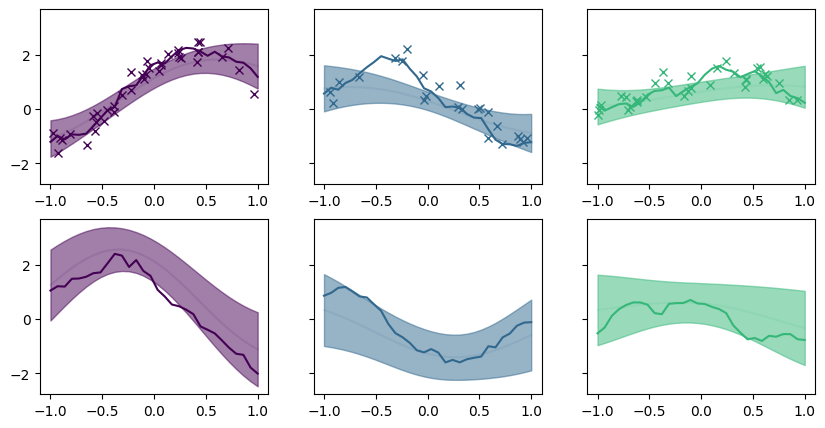

In [9]:
# Plotting the marginal distribution as it looks now
fig, axes = plot_marginal(mySDEproblem, data, state_dim, axes=None, true_states=true_state_series, 
                          true_states_ts=generator_SDE.ts, num_samples=100, max_num_data=3, device=device, observation_dim=observation_dim, data_mask=emissions_mask)
plt.show()


In [10]:
# train loop
saved_parameter_dict = {}

all_train_losses = []
batch_size = 100
max_step_no = 1520
with torch_seed(0):
    #train_loader_ = DataLoader(data, batch_size=batch_size)
    dataset = TensorDataset(data, emissions_mask, true_state_series)
    train_loader_ = DataLoader(dataset, batch_size=batch_size, shuffle=True)
epoch_loss = []
epoch_diffusion_loss = []
epoch_prior_loss = []
epoch_reconstruction_loss = []

# saving the true parameters for later comparison
true_parameter_dict ={}
save_models(true_parameter_dict, [generator_drift, generator_diffusion, generator_emission, generator_prior])

# list of models for plotting 
models_to_be_saved = [mydrift, mydiffusion, myemission, myprior]
saved_models = []

num_batches_train = len(train_loader_)
epoch_steps = []
step_no = 0
epoch = 0
plot_every_epoch = 100
plot_parameters_every_epoch = 100
print_every_epoch = 10

# We want to train in two tempi, since the training of the marginal otherwise becomes unstable.
params_for_optim1 = [{"params": m.named_parameters()} for m in [mydrift, mydiffusion, myemission, myprior] if len(dict(m.named_parameters()))>0]
params_for_optim2 = mySDEproblem.marginal.named_parameters()
diffusion_weight = 1
lr1 = torch.tensor(0.2)
lr2 = torch.tensor(0.004)
optimizer1 = torch.optim.Adam(params_for_optim1, lr=lr1)
optimizer2 = torch.optim.Adam(params_for_optim2, lr=lr2)
scheduler=None

epoch=10, 	step=20, 	loss=40.764388, 	diff loss=5.002181, 	prior loss=1.619095, 	rec loss=34.143112,
epoch=20, 	step=40, 	loss=36.074559, 	diff loss=3.936722, 	prior loss=1.643742, 	rec loss=30.494095,
epoch=30, 	step=60, 	loss=31.407001, 	diff loss=4.002393, 	prior loss=1.628970, 	rec loss=25.775638,
epoch=40, 	step=80, 	loss=31.425665, 	diff loss=4.135237, 	prior loss=1.636226, 	rec loss=25.654203,
epoch=50, 	step=100, 	loss=30.095183, 	diff loss=4.113838, 	prior loss=1.647789, 	rec loss=24.333557,
epoch=60, 	step=120, 	loss=28.144744, 	diff loss=4.133541, 	prior loss=1.670066, 	rec loss=22.341137,
epoch=70, 	step=140, 	loss=26.589634, 	diff loss=3.982935, 	prior loss=1.650400, 	rec loss=20.956299,
epoch=80, 	step=160, 	loss=26.468140, 	diff loss=4.236116, 	prior loss=1.653279, 	rec loss=20.578746,
epoch=90, 	step=180, 	loss=26.041910, 	diff loss=4.708773, 	prior loss=1.698248, 	rec loss=19.634889,
epoch=100, 	step=200, 	loss=24.496278, 	diff loss=4.642733, 	prior loss=1.738789, 	rec

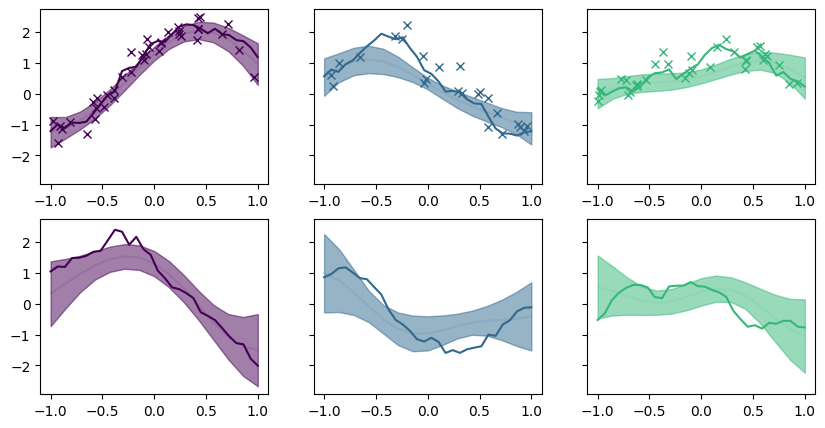

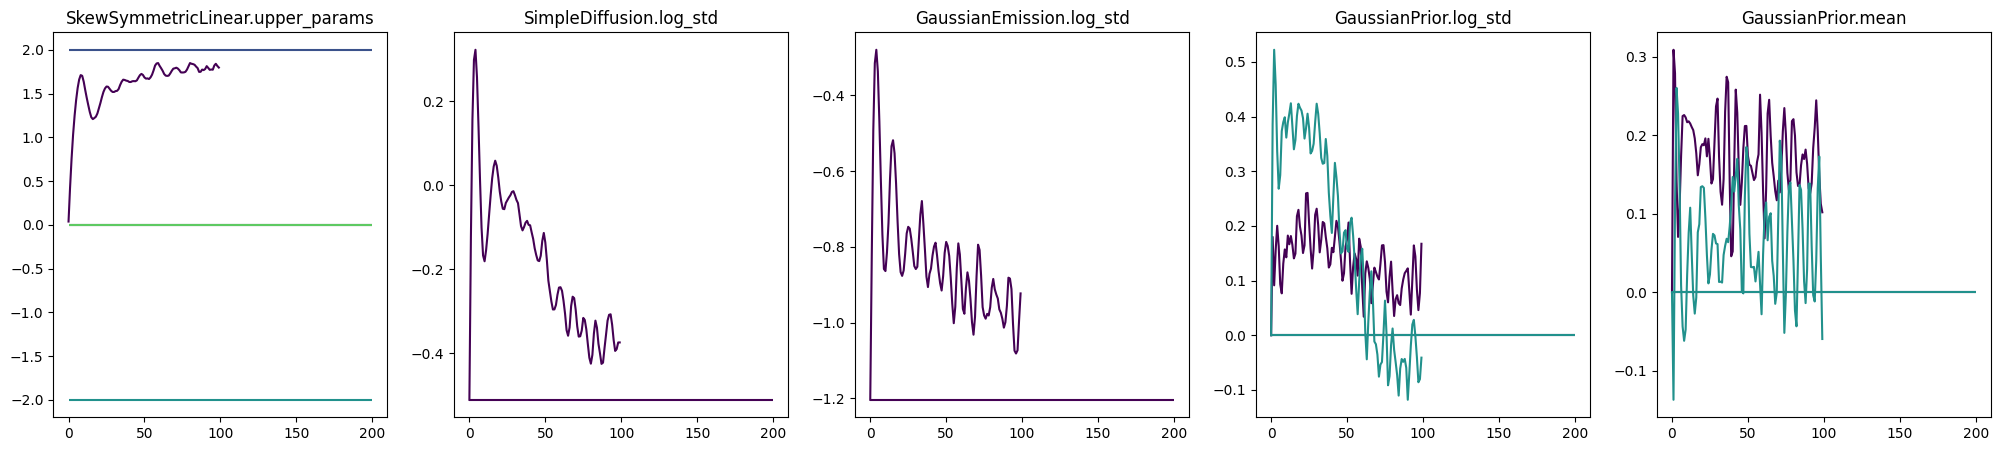

epoch=110, 	step=220, 	loss=25.215934, 	diff loss=5.124994, 	prior loss=1.726592, 	rec loss=18.364348,
epoch=120, 	step=240, 	loss=23.495630, 	diff loss=5.304208, 	prior loss=1.735967, 	rec loss=16.455456,
epoch=130, 	step=260, 	loss=24.543340, 	diff loss=5.644860, 	prior loss=1.761293, 	rec loss=17.137186,
epoch=140, 	step=280, 	loss=24.443045, 	diff loss=5.670818, 	prior loss=1.773356, 	rec loss=16.998871,
epoch=150, 	step=300, 	loss=23.200005, 	diff loss=6.033469, 	prior loss=1.857162, 	rec loss=15.309374,
epoch=160, 	step=320, 	loss=24.409632, 	diff loss=6.152551, 	prior loss=1.833573, 	rec loss=16.423508,
epoch=170, 	step=340, 	loss=24.214425, 	diff loss=6.244105, 	prior loss=1.868659, 	rec loss=16.101661,
epoch=180, 	step=360, 	loss=23.628667, 	diff loss=6.460642, 	prior loss=1.813800, 	rec loss=15.354224,
epoch=190, 	step=380, 	loss=21.771196, 	diff loss=6.563204, 	prior loss=1.856140, 	rec loss=13.351853,
epoch=200, 	step=400, 	loss=22.763276, 	diff loss=6.861027, 	prior loss=1

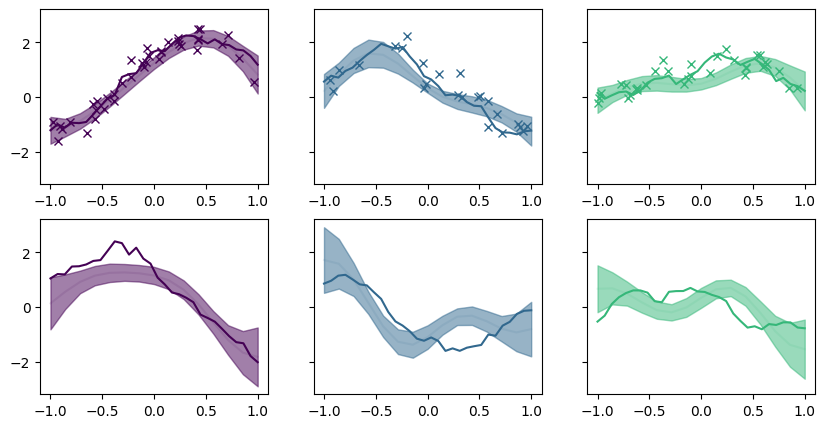

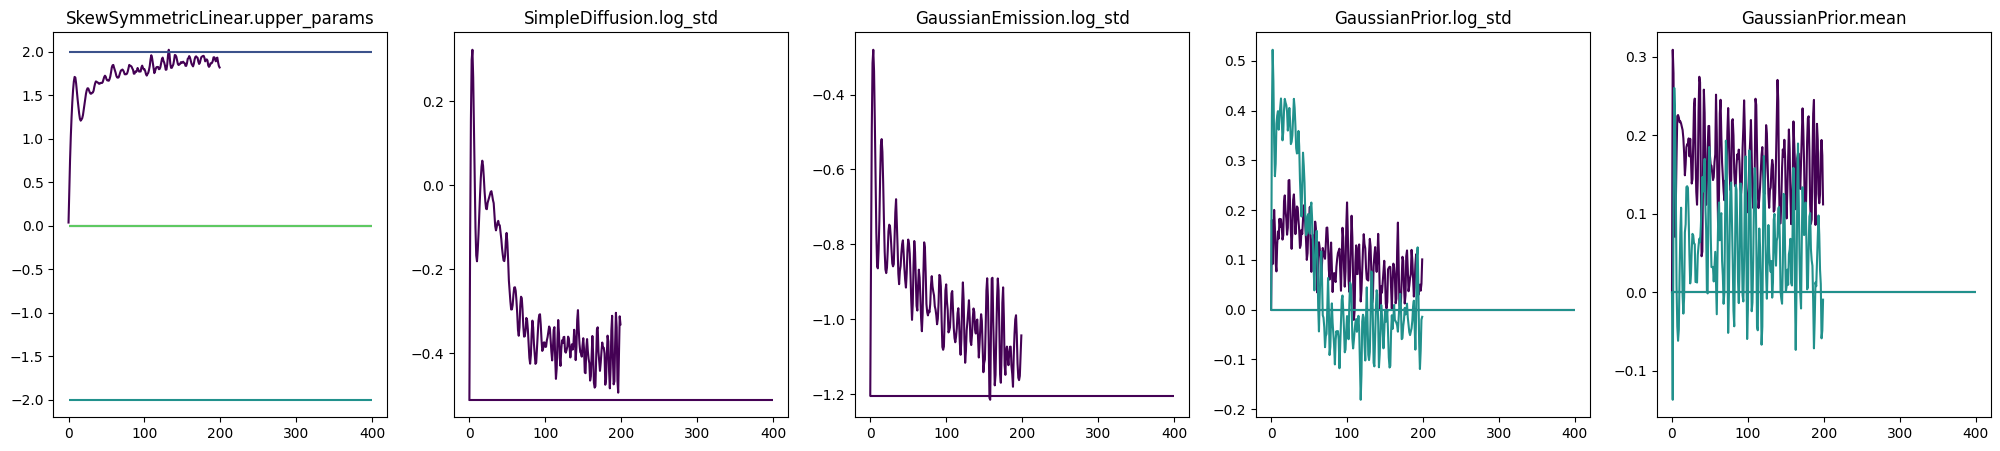

epoch=210, 	step=420, 	loss=22.441534, 	diff loss=7.188229, 	prior loss=1.812587, 	rec loss=13.440717,
epoch=220, 	step=440, 	loss=22.524395, 	diff loss=7.243915, 	prior loss=1.835987, 	rec loss=13.444493,
epoch=230, 	step=460, 	loss=22.504565, 	diff loss=7.101191, 	prior loss=1.846023, 	rec loss=13.557350,
epoch=240, 	step=480, 	loss=23.993299, 	diff loss=7.093194, 	prior loss=1.899995, 	rec loss=15.000112,
epoch=250, 	step=500, 	loss=23.928031, 	diff loss=7.491630, 	prior loss=1.882860, 	rec loss=14.553541,
epoch=260, 	step=520, 	loss=23.229925, 	diff loss=7.586524, 	prior loss=1.886427, 	rec loss=13.756974,
epoch=270, 	step=540, 	loss=22.610734, 	diff loss=7.441825, 	prior loss=1.867071, 	rec loss=13.301838,
epoch=280, 	step=560, 	loss=22.606801, 	diff loss=7.751949, 	prior loss=1.914447, 	rec loss=12.940405,
epoch=290, 	step=580, 	loss=23.629029, 	diff loss=7.522885, 	prior loss=1.907120, 	rec loss=14.199025,
epoch=300, 	step=600, 	loss=23.736284, 	diff loss=7.788083, 	prior loss=1

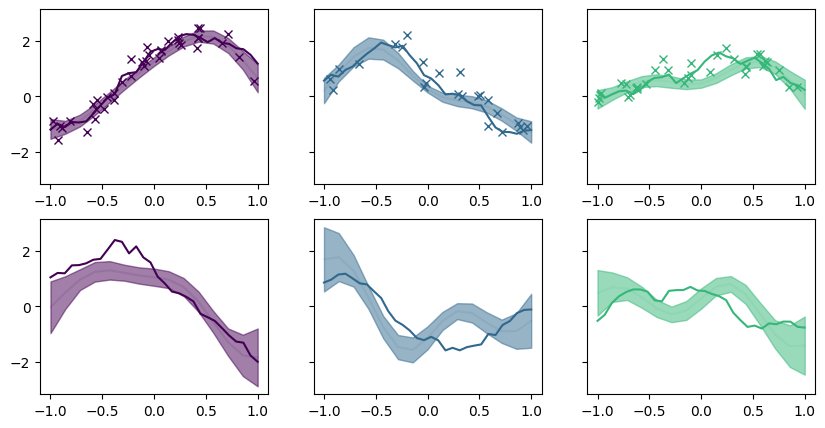

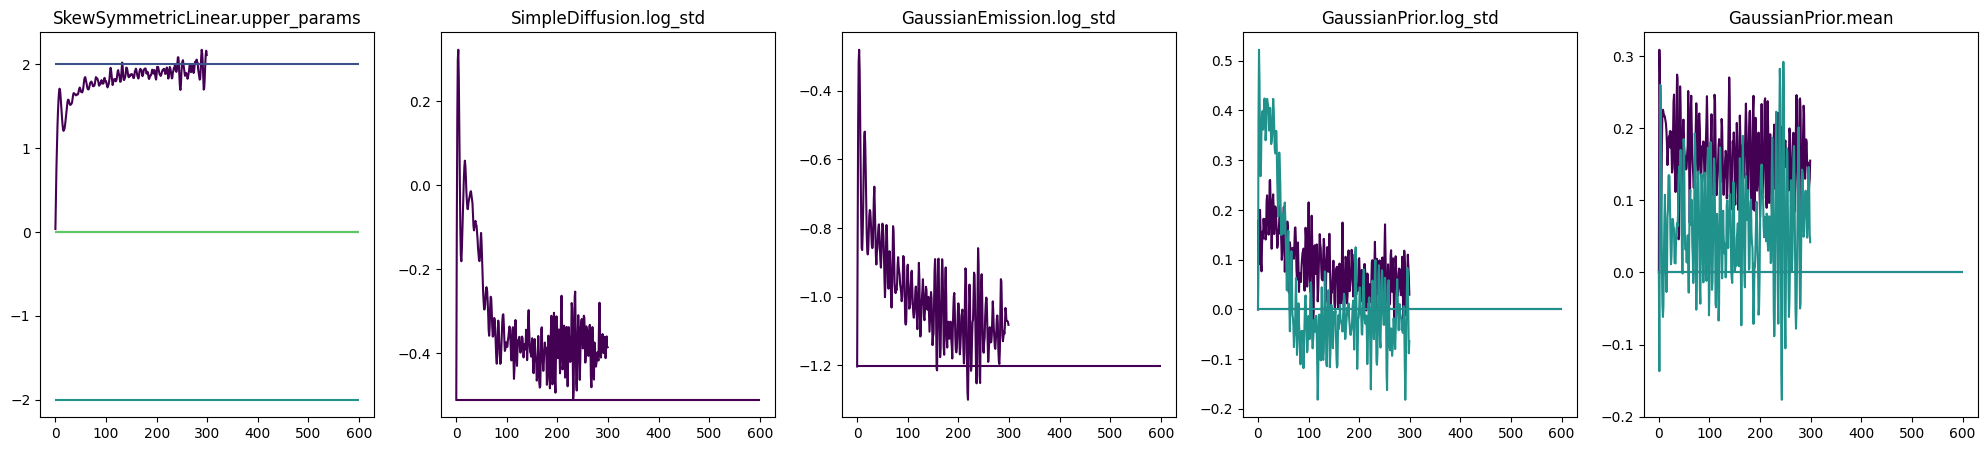

epoch=310, 	step=620, 	loss=23.984479, 	diff loss=8.202703, 	prior loss=1.893160, 	rec loss=13.888616,
epoch=320, 	step=640, 	loss=23.149478, 	diff loss=7.956710, 	prior loss=1.933822, 	rec loss=13.258945,
epoch=330, 	step=660, 	loss=23.548342, 	diff loss=7.847998, 	prior loss=1.935908, 	rec loss=13.764436,
epoch=340, 	step=680, 	loss=21.584007, 	diff loss=7.845724, 	prior loss=1.943795, 	rec loss=11.794488,
epoch=350, 	step=700, 	loss=22.821160, 	diff loss=7.990088, 	prior loss=1.946593, 	rec loss=12.884479,
epoch=360, 	step=720, 	loss=23.209934, 	diff loss=7.684056, 	prior loss=1.973808, 	rec loss=13.552069,
epoch=370, 	step=740, 	loss=22.965258, 	diff loss=7.624975, 	prior loss=1.975943, 	rec loss=13.364341,
epoch=380, 	step=760, 	loss=21.941133, 	diff loss=7.890773, 	prior loss=1.955820, 	rec loss=12.094539,
epoch=390, 	step=780, 	loss=23.010803, 	diff loss=7.879902, 	prior loss=1.942360, 	rec loss=13.188541,
epoch=400, 	step=800, 	loss=22.400344, 	diff loss=7.665402, 	prior loss=1

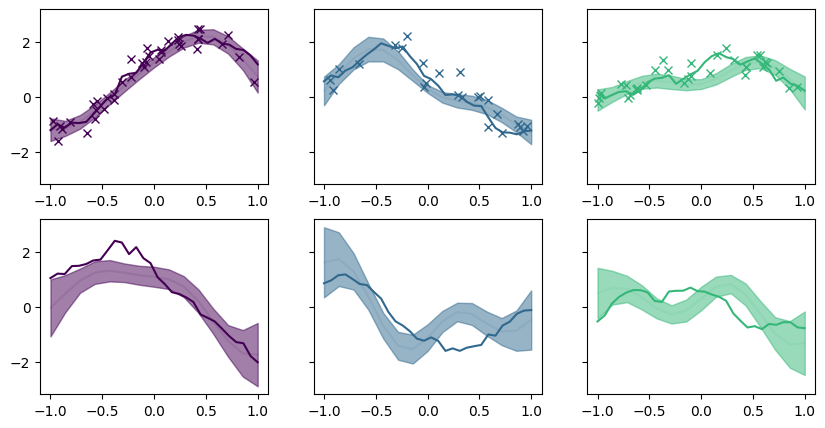

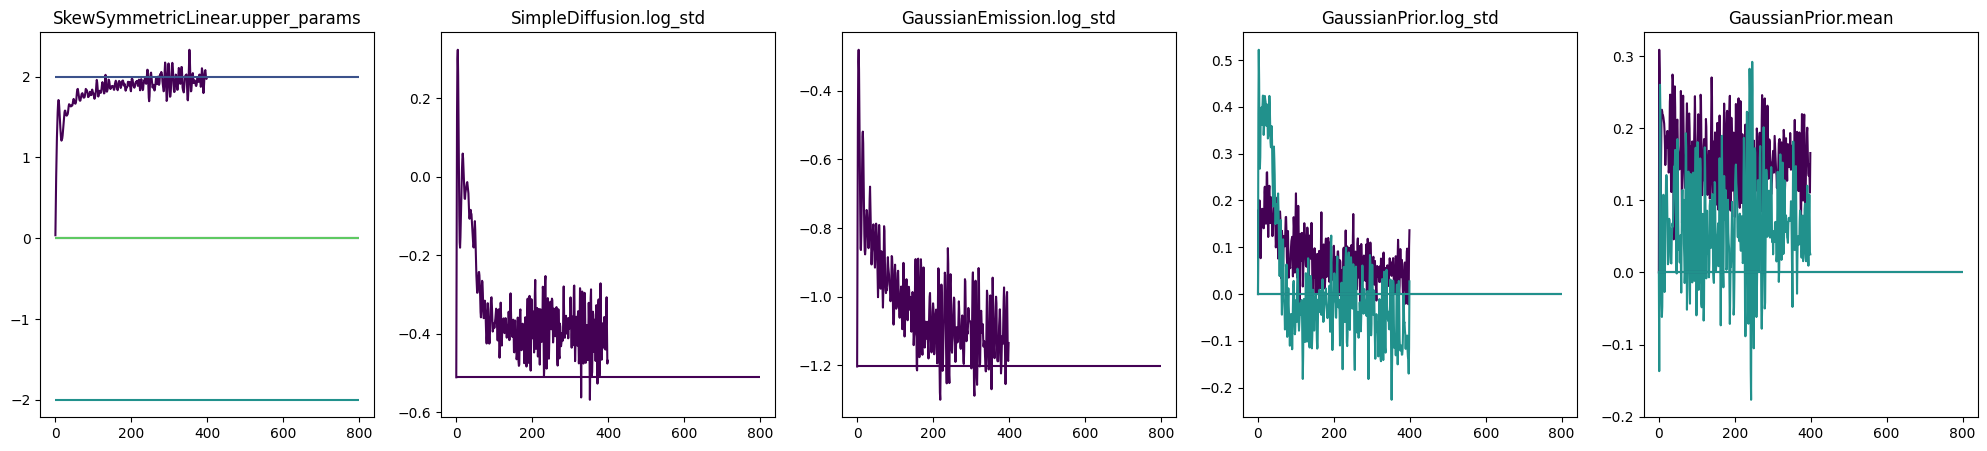

epoch=410, 	step=820, 	loss=22.670514, 	diff loss=7.737193, 	prior loss=1.937702, 	rec loss=12.995620,
epoch=420, 	step=840, 	loss=22.558822, 	diff loss=7.837312, 	prior loss=1.938200, 	rec loss=12.783310,
epoch=430, 	step=860, 	loss=23.506610, 	diff loss=7.780826, 	prior loss=1.920616, 	rec loss=13.805168,
epoch=440, 	step=880, 	loss=21.881386, 	diff loss=7.834041, 	prior loss=1.917297, 	rec loss=12.130048,
epoch=450, 	step=900, 	loss=22.884656, 	diff loss=7.520354, 	prior loss=1.920064, 	rec loss=13.444239,
epoch=460, 	step=920, 	loss=23.185309, 	diff loss=8.052330, 	prior loss=1.932635, 	rec loss=13.200345,
epoch=470, 	step=940, 	loss=22.392767, 	diff loss=8.064898, 	prior loss=1.923543, 	rec loss=12.404325,
epoch=480, 	step=960, 	loss=22.069546, 	diff loss=8.182658, 	prior loss=1.912485, 	rec loss=11.974402,
epoch=490, 	step=980, 	loss=22.429490, 	diff loss=8.005938, 	prior loss=1.929478, 	rec loss=12.494074,
epoch=500, 	step=1000, 	loss=22.713628, 	diff loss=8.153181, 	prior loss=

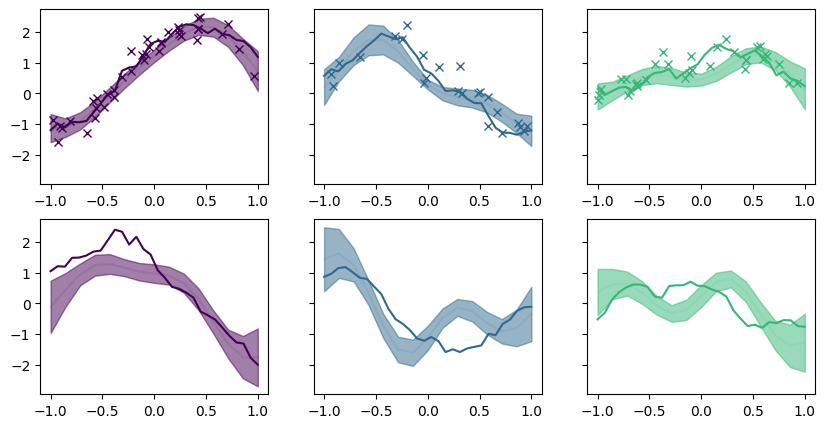

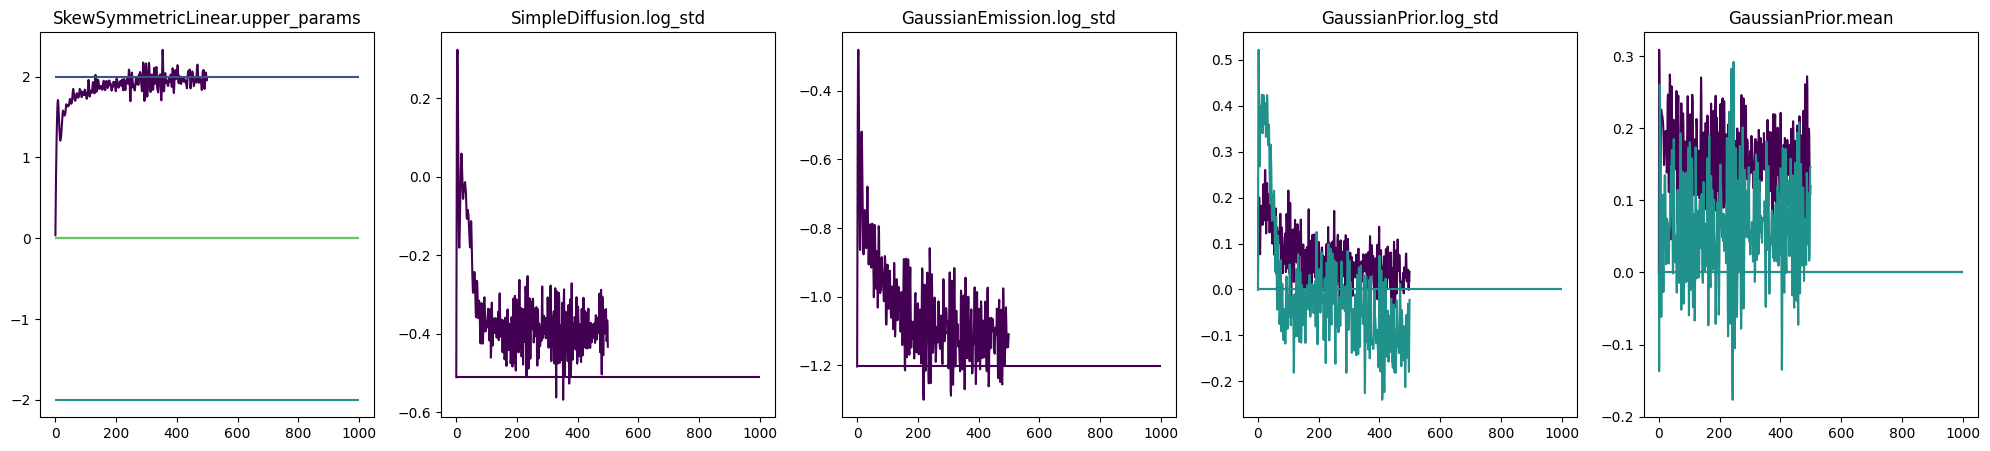

epoch=510, 	step=1020, 	loss=23.114884, 	diff loss=8.074551, 	prior loss=1.924516, 	rec loss=13.115817,
epoch=520, 	step=1040, 	loss=23.082200, 	diff loss=7.860488, 	prior loss=1.887424, 	rec loss=13.334288,
epoch=530, 	step=1060, 	loss=22.873084, 	diff loss=8.175314, 	prior loss=1.904295, 	rec loss=12.793476,
epoch=540, 	step=1080, 	loss=23.215836, 	diff loss=8.247546, 	prior loss=1.913378, 	rec loss=13.054912,
epoch=550, 	step=1100, 	loss=23.708664, 	diff loss=7.922425, 	prior loss=1.920537, 	rec loss=13.865702,
epoch=560, 	step=1120, 	loss=22.883871, 	diff loss=7.916417, 	prior loss=1.960286, 	rec loss=13.007168,
epoch=570, 	step=1140, 	loss=24.231890, 	diff loss=7.633787, 	prior loss=1.941080, 	rec loss=14.657024,
epoch=580, 	step=1160, 	loss=22.030729, 	diff loss=7.636379, 	prior loss=1.943184, 	rec loss=12.451166,
epoch=590, 	step=1180, 	loss=22.862589, 	diff loss=8.052030, 	prior loss=1.964674, 	rec loss=12.845885,
epoch=600, 	step=1200, 	loss=23.561374, 	diff loss=8.039764, 	pr

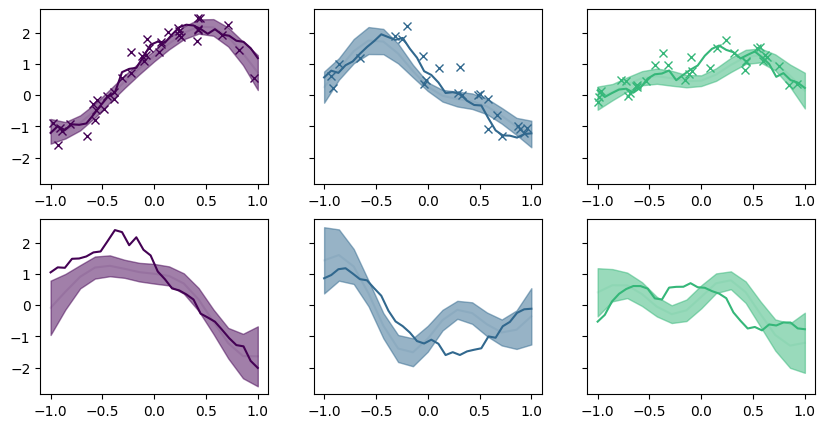

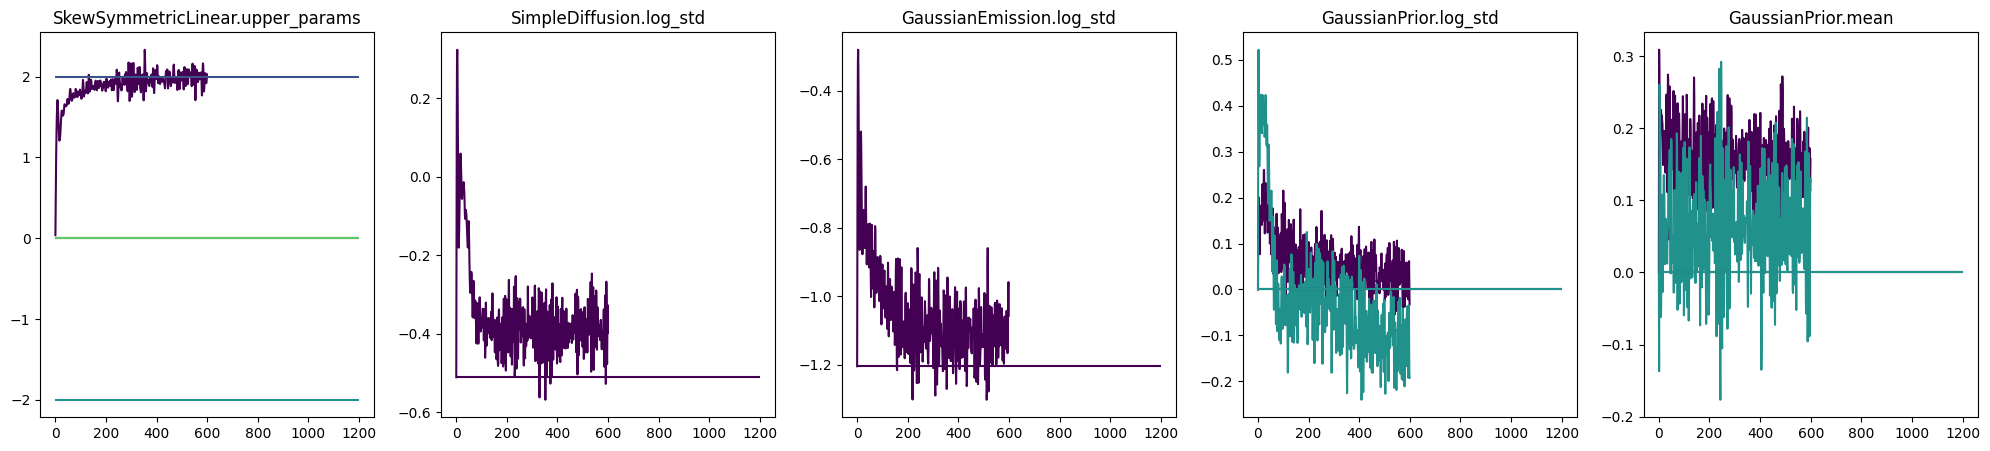

epoch=610, 	step=1220, 	loss=21.982941, 	diff loss=7.905575, 	prior loss=1.912902, 	rec loss=12.164465,
epoch=620, 	step=1240, 	loss=23.094649, 	diff loss=7.988062, 	prior loss=1.965719, 	rec loss=13.140869,
epoch=630, 	step=1260, 	loss=23.196794, 	diff loss=7.758068, 	prior loss=1.961919, 	rec loss=13.476807,
epoch=640, 	step=1280, 	loss=23.864628, 	diff loss=8.167414, 	prior loss=1.976374, 	rec loss=13.720840,
epoch=650, 	step=1300, 	loss=23.442272, 	diff loss=7.972915, 	prior loss=1.928463, 	rec loss=13.540894,
epoch=660, 	step=1320, 	loss=22.656794, 	diff loss=7.936401, 	prior loss=1.951100, 	rec loss=12.769293,
epoch=670, 	step=1340, 	loss=22.549652, 	diff loss=8.005282, 	prior loss=1.959908, 	rec loss=12.584462,
epoch=680, 	step=1360, 	loss=23.173230, 	diff loss=7.902073, 	prior loss=1.967885, 	rec loss=13.303270,
epoch=690, 	step=1380, 	loss=22.959059, 	diff loss=7.907560, 	prior loss=1.971366, 	rec loss=13.080132,
epoch=700, 	step=1400, 	loss=22.813586, 	diff loss=7.753231, 	pr

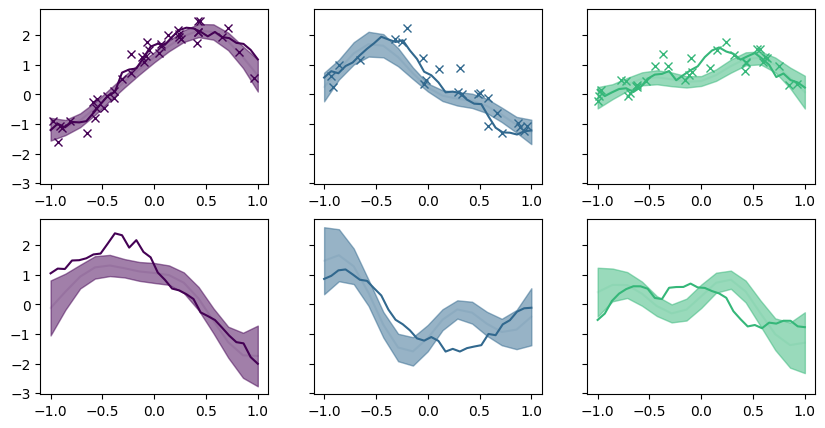

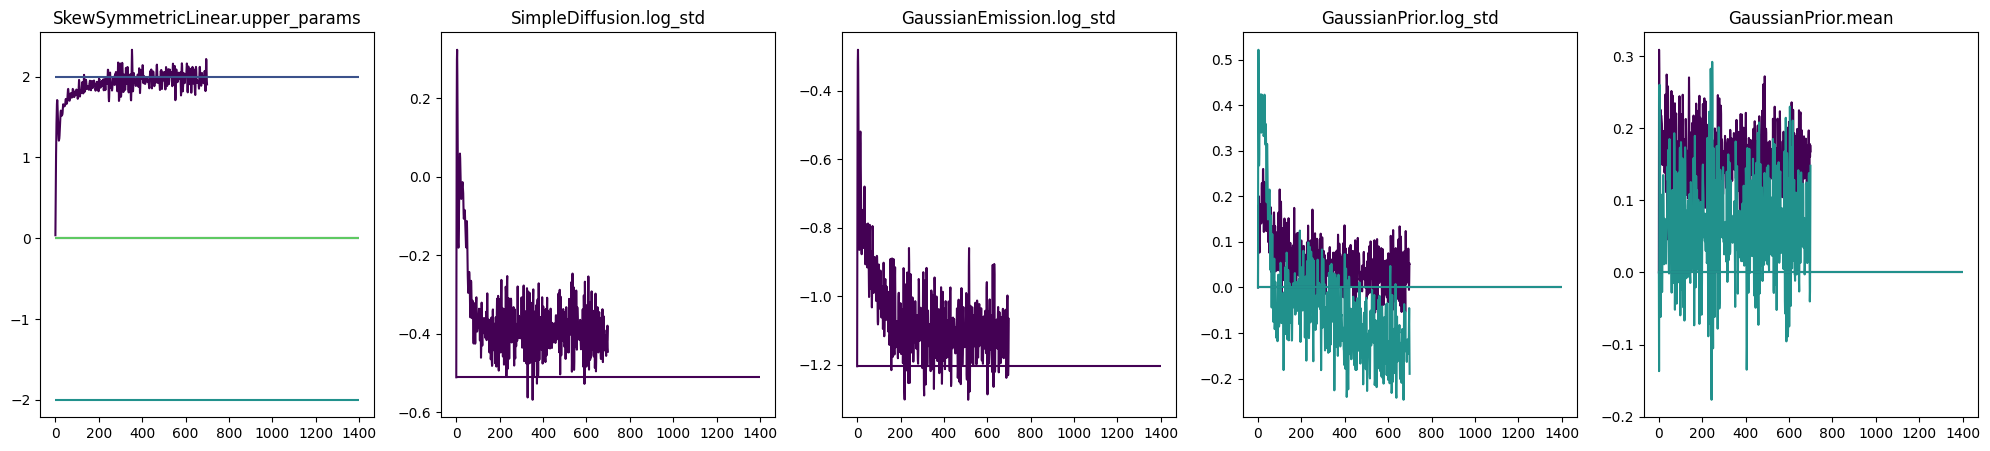

epoch=710, 	step=1420, 	loss=24.033324, 	diff loss=7.938228, 	prior loss=2.032476, 	rec loss=14.062620,
epoch=720, 	step=1440, 	loss=22.144714, 	diff loss=7.522424, 	prior loss=1.959684, 	rec loss=12.662606,
epoch=730, 	step=1460, 	loss=23.963080, 	diff loss=8.067448, 	prior loss=1.908772, 	rec loss=13.986860,
epoch=740, 	step=1480, 	loss=22.520463, 	diff loss=8.040131, 	prior loss=1.957405, 	rec loss=12.522927,
epoch=750, 	step=1500, 	loss=23.503067, 	diff loss=8.165776, 	prior loss=1.958558, 	rec loss=13.378733,
epoch=760, 	step=1520, 	loss=22.711247, 	diff loss=8.093503, 	prior loss=1.880653, 	rec loss=12.737092,


In [11]:
while True:
    epoch_loss.append(0) 
    epoch_diffusion_loss.append(0) 
    epoch_prior_loss.append(0) 
    epoch_reconstruction_loss.append(0) 

    epoch += 1
    save_models(saved_parameter_dict, models_to_be_saved)

    for data_batch, mask_batch, states_batch in train_loader_:
        this_batch_size = len(data_batch)
        mySDEproblem.train()
        optimizer1.zero_grad()
        optimizer2.zero_grad()
        diffusion_loss, prior_loss, reconstruction_loss = mySDEproblem.ELBO(data_batch, mask_batch)
        sum_loss = (diffusion_loss*diffusion_weight + prior_loss*1 + reconstruction_loss).mean(dim=0)
        sum_loss.backward()
        all_train_losses.append(sum_loss.item())
        epoch_loss[-1] += sum_loss.item() / num_batches_train
        epoch_diffusion_loss[-1] += diffusion_loss.mean(dim=0).item() / num_batches_train
        epoch_prior_loss[-1] += prior_loss.mean(dim=0).item() / num_batches_train
        epoch_reconstruction_loss[-1] += reconstruction_loss.mean(dim=0).item() / num_batches_train
        step_no += 1

        optimizer1.step()
        optimizer2.step()

    if (epoch % print_every_epoch) ==0:
        string1 = f"epoch={len(epoch_loss)}, \tstep={step_no}, "
        string2 = f"\tloss={sum(epoch_loss[-print_every_epoch:])/print_every_epoch :2.6f}, \tdiff loss={sum(epoch_diffusion_loss[-print_every_epoch:])/print_every_epoch :2.6f}, "
        string3 = f"\tprior loss={sum(epoch_prior_loss[-print_every_epoch:])/print_every_epoch :2.6f}, \trec loss={sum(epoch_reconstruction_loss[-print_every_epoch:])/print_every_epoch :2.6f},"
        print(string1 + string2 + string3)

    if (epoch % plot_every_epoch)==0:
        fig, axes = plot_marginal(mySDEproblem, data, state_dim, axes=None, true_states=true_state_series, 
                          true_states_ts=generator_SDE.ts, num_samples=100, num_timesteps = 15, max_num_data=3, device=device, observation_dim=observation_dim, data_mask=emissions_mask)
        plt.show()

    if (epoch % plot_parameters_every_epoch)==0:
        fig, axes = plot_parameter_history(true_parameter_dict, saved_parameter_dict, epoch)
        plt.show()
        #pass

    if scheduler:
        scheduler.step()
    if step_no >= max_step_no: break


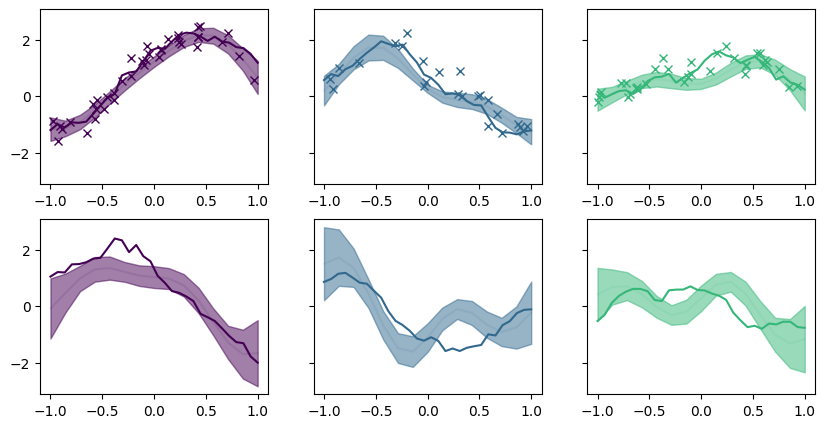

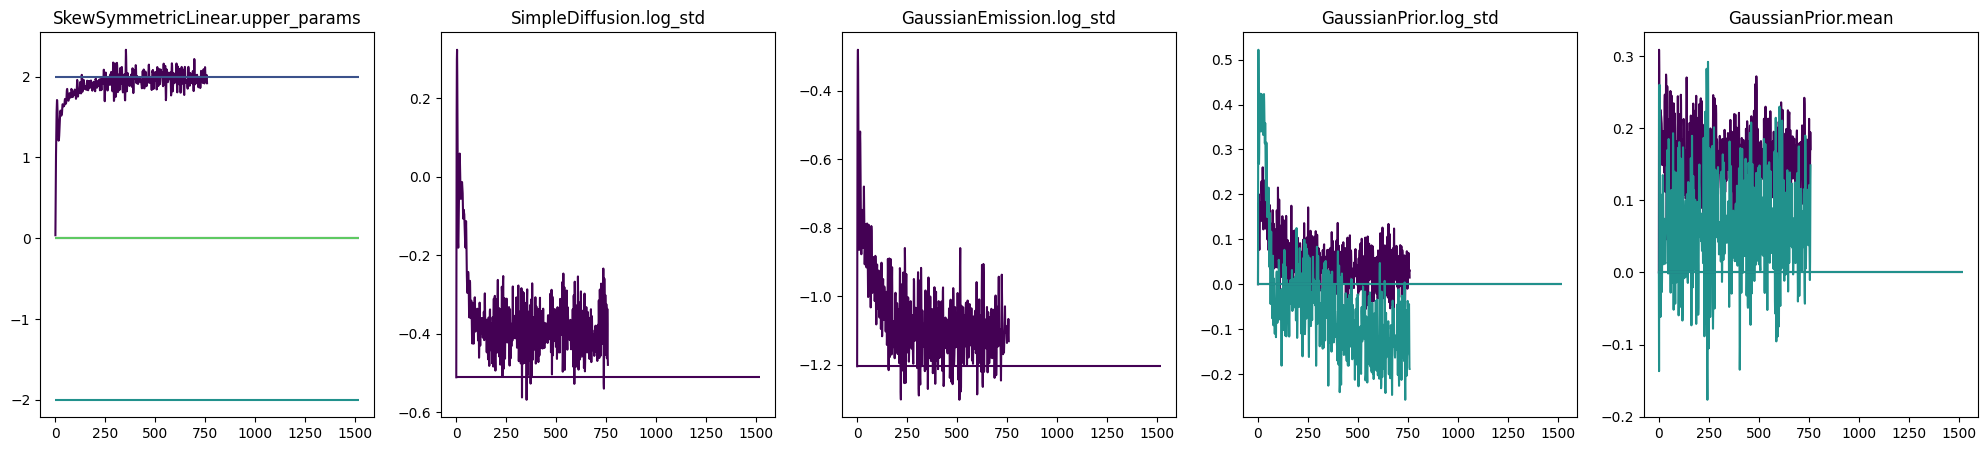

In [12]:
fig, axes = plot_marginal(mySDEproblem, data, state_dim, axes=None, true_states=true_state_series, 
                    true_states_ts=generator_SDE.ts, num_samples=100, num_timesteps = 15, max_num_data=3, device=device, observation_dim=observation_dim, data_mask=emissions_mask)
plt.show()

fig, axes = plot_parameter_history(true_parameter_dict, saved_parameter_dict, step_no)
plt.show()


### Parameters after training

In [13]:
print(f"Total parameters in mySDEproblem: {sum(p.numel() for p in mySDEproblem.parameters())}")
for k in dict(mySDEproblem.named_parameters()).keys():
    print(k)

print("\n\nGenerating modules parameters")
for net in [generator_drift, generator_diffusion, generator_emission, generator_prior]:
    print(f"\n{net._get_name()}:")
    print(dict(net.named_parameters()))

print("\n\nSolving modules parameters")
for net in [mydrift, mydiffusion, myemission, myprior, condition_mapper, marginal_func]:
    print(f"\n{net._get_name()}:")
    print(dict(net.named_parameters()))

Total parameters in mySDEproblem: 14
drift.upper_params
diffusion.log_std
prior.log_std
prior.mean
condition_mapper.W
condition_mapper.kernel.log_l
condition_mapper.kernel.log_sigma_f
condition_mapper.kernel.log_sigma_n
emission.log_std


Generating modules parameters

LinearDrift:
{'linear.weight': Parameter containing:
tensor([[ 0.,  2.],
        [-2.,  0.]], device='mps:0', requires_grad=True)}

SimpleDiffusion:
{'log_std': Parameter containing:
tensor(-0.5108, device='mps:0', requires_grad=True)}

GaussianEmission:
{'log_std': Parameter containing:
tensor(-1.2040, device='mps:0', requires_grad=True)}

GaussianPrior:
{'log_std': Parameter containing:
tensor([0., 0.], device='mps:0', requires_grad=True), 'mean': Parameter containing:
tensor([0., 0.], device='mps:0', requires_grad=True)}


Solving modules parameters

SkewSymmetricLinear:
{'upper_params': Parameter containing:
tensor([1.9002], device='mps:0', requires_grad=True)}

SimpleDiffusion:
{'log_std': Parameter containing:
tens

# Conclusion
As we can see here, the model actually converges to the correct parameters. Horray! 

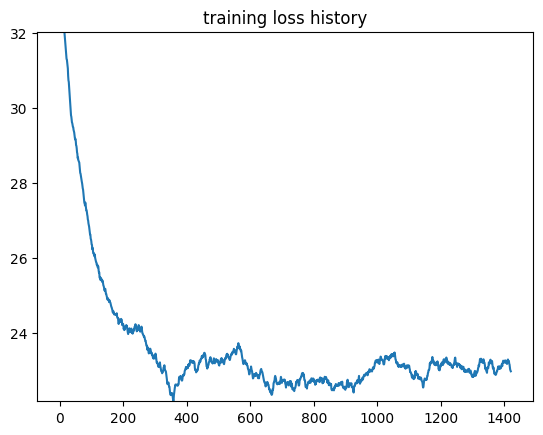

In [14]:

all_train_losses_t = torch.tensor(all_train_losses)

def moving_average(a, n=3):
    ret = a.cumsum(dim=0)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

train_loss_ma = moving_average(all_train_losses_t, 100)
plt.plot(train_loss_ma)
plt.ylim(train_loss_ma.min(), torch.quantile(train_loss_ma, .99))
plt.title("training loss history")
plt.show()
